# MicroProyecto # 1 de Machine Learning No Supervisado — MAIA

**Nombre de los estudiantes:**  Jairo Alexander López Garcia -  Miguel Angel Rodriguez Marin

**Código:**  `202615506`  -  `202612426`

**Maestría:** Maestría en Inteligencia Artificial (MAIA)

**Fecha:**  06/09/2026


## 0. Importación de librerías requeridas

Importaremos las librerías `numpy`, `os` y `cv2` para la carga y procesamiento de las imágenes, así como la librería `scikit_learn` para usar los algoritmos de agrupación y la librería `matplotlib` para visualizar las imágenes resultantes:

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

## 1. Recopilación de un conjunto diverso de imágenes en diferentes estilos artísticos

Recopilación de un conjunto diverso de imágenes en diferentes estilos artísticos (al menos tres estilos o pintores), a partir del repositorio. Al comienzo del notebook se deben mostrar las imágenes seleccionadas (entre 6 – 10 imágenes), explicando, de manera breve, la motivación para su selección.

<h3>Imágenes del conjunto de datos</h3>

Estas imágenes fueron elegidas porque representan diferentes corrientes artísticas y contienen una amplia diversidad cromática. Esto resulta útil para comprobar si el modelo es capaz de agrupar correctamente los colores presentes en cada una de ellas. Asimismo, al contar con varias  tonalidades de alto contraste, se puede validar con una mejor claridad si la clasificación y la creación de la paleta de colores se están realizando de manera correcta.

Las cuales son las siguientes:

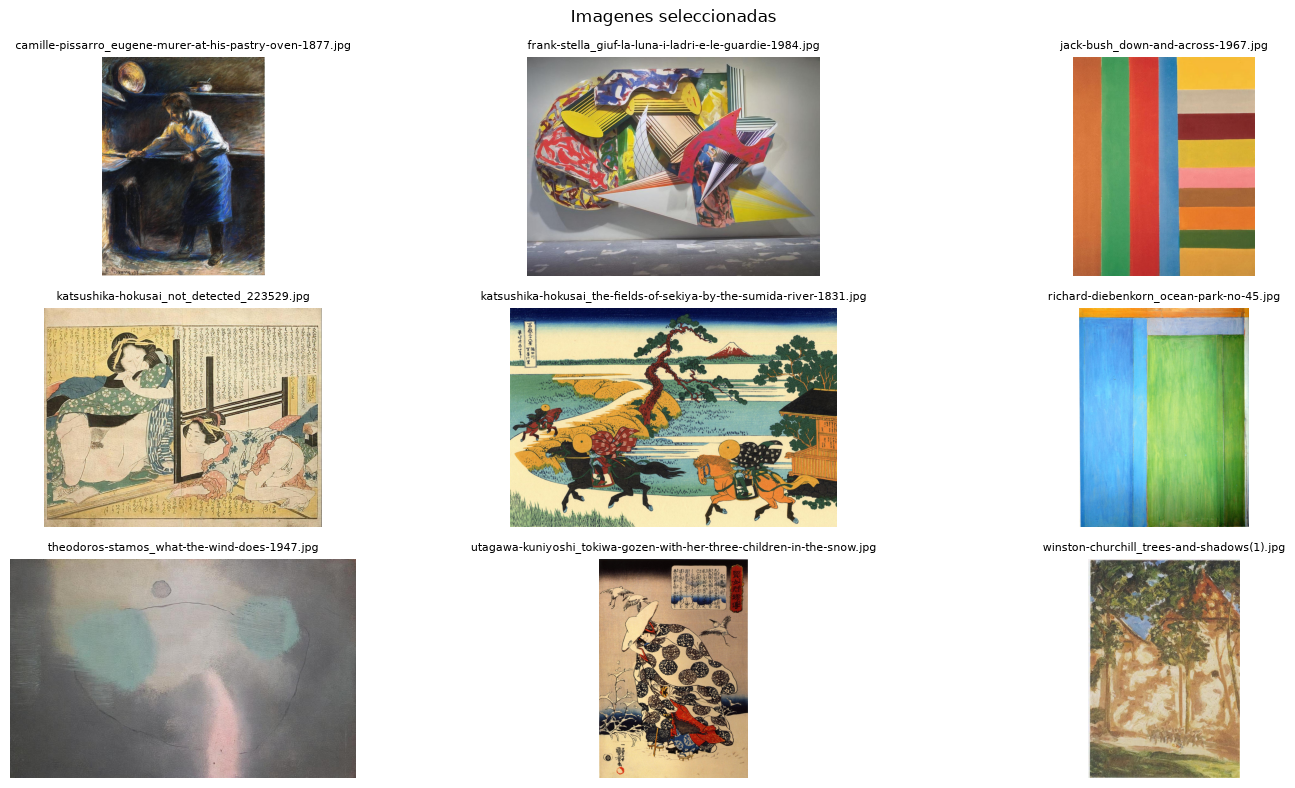

In [2]:
imagenes = []

carpeta_imagenes = 'imagenes'

figura, ejes = plt.subplots(3, 3, figsize=(16, 8))

for carpeta_actual, subcarpetas, archivos in os.walk(carpeta_imagenes):
    for archivo in archivos:
        if archivo.lower().endswith(('.jpg')):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            imagenes.append([ruta_completa, archivo])

for posicion in range(len(imagenes)):
    ruta, archivo = imagenes[posicion]

    imagen_rgb = plt.imread(ruta)

    ejes.flat[posicion].imshow(imagen_rgb)
    ejes.flat[posicion].set_title(archivo, fontsize=8)
    ejes.flat[posicion].axis('off')

plt.suptitle('Imagenes seleccionadas')
plt.tight_layout()
plt.show()

## 2. Preparación de los datos
### 2.1 Carga de los datos 

Las imagenes las almacenamos en una carpeta llamada "imagenes"; posteriormente creamos una funcion `cargar_imagenes()` para la carga de las imágenes de la carpeta y utilizaremos funciones como `imread()` y `cvtColor()` para realizar la carga y procesamiento de cada una:

In [3]:
root_path = 'imagenes'
img_files = os.listdir(root_path)
img_files

['camille-pissarro_eugene-murer-at-his-pastry-oven-1877.jpg',
 'frank-stella_giuf-la-luna-i-ladri-e-le-guardie-1984.jpg',
 'jack-bush_down-and-across-1967.jpg',
 'katsushika-hokusai_not_detected_223529.jpg',
 'katsushika-hokusai_the-fields-of-sekiya-by-the-sumida-river-1831.jpg',
 'richard-diebenkorn_ocean-park-no-45.jpg',
 'theodoros-stamos_what-the-wind-does-1947.jpg',
 'utagawa-kuniyoshi_tokiwa-gozen-with-her-three-children-in-the-snow.jpg',
 'winston-churchill_trees-and-shadows(1).jpg']

In [4]:
def cargar_imagenes(root_path, file_names):
    image_list = list()
    for file in file_names:
        img = cv2.imread(os.path.join(root_path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image_list.append(img)
    return image_list

Cargamos las imagenes originales sin modificaciones en el arreglo 'img_original'  para despues ser utilizadas en el modelo generado

In [5]:
img_original = cargar_imagenes(root_path, img_files)
img_original

[array([[[ 54,  54,  54],
         [ 58,  58,  58],
         [ 61,  61,  61],
         ...,
         [111, 110,  92],
         [215, 213, 200],
         [220, 221, 207]],
 
        [[ 65,  65,  65],
         [ 64,  64,  64],
         [ 62,  62,  62],
         ...,
         [114, 113,  95],
         [219, 217, 204],
         [226, 227, 213]],
 
        [[ 62,  62,  62],
         [ 62,  62,  62],
         [ 62,  62,  62],
         ...,
         [108, 107,  89],
         [213, 211, 198],
         [220, 221, 207]],
 
        ...,
 
        [[248, 250, 245],
         [250, 252, 247],
         [250, 252, 247],
         ...,
         [245, 251, 251],
         [240, 249, 248],
         [242, 252, 251]],
 
        [[249, 254, 250],
         [244, 250, 246],
         [241, 246, 242],
         ...,
         [245, 251, 251],
         [245, 254, 253],
         [246, 255, 254]],
 
        [[236, 238, 233],
         [236, 241, 235],
         [240, 242, 239],
         ...,
         [248, 252, 251],
  

### 2.2 Normalización de los datos
Se creó la función preparar_imagen() la cual recibe una imagen y la normaliza convertiendola en una lista de píxeles, ajustando sus valores al rango [0, 1]. Esto se hace porque las imágenes están en formato RGB, con esta normalización los valores quedan estandarizados y el conjunto de datos queda en una escala uniforme.

In [6]:
def preparar_imagen(img):
    img = img.reshape((-1, 3))
    img = img / 255.0
    return img

## 3. Construcción del pipeline de preparación de datos.

Creamos un pipeline el cual tiene dos pasos, preparacion que llama la función preparar_imagen() yluego ejecuta el modelo, en este caso se usa el algoritmo de Kmeans. 

In [7]:
def crear_pipeline(num_clusters):
    pipeline = Pipeline([
        ('preparacion', FunctionTransformer(preparar_imagen)),
        ('modelo', KMeans(n_clusters=num_clusters,random_state=42))
    ])
    
    return pipeline

## 4. Construcción del modelo de agrupación con el algoritmo seleccionado con búsqueda de hiperparámetros,.

### 4.1 Funcion de Busqueda de hiperparametros 
Como se mencionó anteriormente, para el modelo de agrupación, se seleccionó K-means como algoritmo principal, permitiendonos agrupar los valores RGB en grupos homogéneos según su similitud, tambien realizando una búsqueda de hiperparámetros para ajustar el número de grupos K, teniendo en cuenta que obra tiene una paleta de colores distinta, con diferente nivel de complejidad y distribución de colores, y al final creamos un método el cual contruye un modelo de agrupación independiente para cada imagen y para ello con el uso del metodo de la silueta porque permite evaluar simultáneamente qué tan cohesionados se encuentran los elementos de un mismo grupo y qué tan separados están respecto a los demás grupos, permitiendo seleccionar el valor de K más adecuado para cada imagen.

In [8]:
def seleccionar_k(img, k_min=3, k_max=20, muestra=5000):
    pixels = preparar_imagen(img)
    # Tomar muestra aleatoria para que sea más rápido
    np.random.seed(42)
    indices = np.random.choice(
        len(pixels),
        size=min(muestra, len(pixels)),
        replace=False
    )
    pixels_muestra = pixels[indices]

    mejor_k = None
    mejor_score = -1
    
    for k in range(k_min, k_max + 1):
        modelo = KMeans(
            n_clusters=k,
            random_state=42
        )
        labels = modelo.fit_predict(pixels_muestra)

        score = silhouette_score(
            pixels_muestra,
            labels
        )
        print(f"K={k} - Silhouette Score={score:.4f}")

        if score > mejor_score:
            mejor_score = score
            mejor_k = k

    print(f"\nMejor número de grupos: {mejor_k}")
    
    return mejor_k

Para probar si la funcion se esta ejecutando correctamente, vamos a probar con la imagen #5 (img_original[5]) del conjunto de imagenes seleccionado, almacenaremos el resultado de K en la variable num_clusters la cual luego la usaremos en el pipeline.

In [9]:
num_clusters = seleccionar_k(img_original[5])

K=3 - Silhouette Score=0.5441
K=4 - Silhouette Score=0.5652
K=5 - Silhouette Score=0.5690
K=6 - Silhouette Score=0.5305
K=7 - Silhouette Score=0.5086
K=8 - Silhouette Score=0.4910
K=9 - Silhouette Score=0.4631
K=10 - Silhouette Score=0.4432
K=11 - Silhouette Score=0.4197
K=12 - Silhouette Score=0.4303
K=13 - Silhouette Score=0.4302
K=14 - Silhouette Score=0.4247
K=15 - Silhouette Score=0.4216
K=16 - Silhouette Score=0.4158
K=17 - Silhouette Score=0.3953
K=18 - Silhouette Score=0.3985
K=19 - Silhouette Score=0.3847
K=20 - Silhouette Score=0.3667

Mejor número de grupos: 5


### 4.2 Construcción de modelo de agrupacion
Para la construcción del modelo de agrupación se ha escogido el algoritomo Kmeans el cual es un algoritmo de aprendizaje no supervisado y nos permite agrupar objetos que comparten caracterisitcas similares, en este caso, colores similares.

Para ejecutar el Pipeline, el cual tiene la preparacion de la imagen y luego la ejecución del algoritmo vamos a tomar la imagen 5 del conjunto de imagen y entregamos al pipeline el hiperparametro K el cual habiamos calculado previamente y almacenamos en la variable num_clusters

In [10]:
pipeline = crear_pipeline(num_clusters)
pipeline.fit(img_original[5])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1382
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...00230AA06D9B0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


Almacenamos el resultado del modelo, el centroide obtenido y las etiquetas, las cuales las usaremos para la construcción de la paleta.

In [11]:
kmeans_model = pipeline.named_steps['modelo']
labels = kmeans_model.labels_
centroids = kmeans_model.cluster_centers_


## 5.Construcción de la función que transforma los grupos de colores identificados en un muestrario representativo

Creamos la funcion que nos permite crear la paleta de colores, la cual toma como color dominante el centroide.

In [12]:
def crear_paleta(colors, counts, width=600, height=120):
    paleta = np.zeros((height, width, 3), dtype=np.uint8)
    
    total = counts.sum()
    start_x = 0
    
    for color, count in zip(colors, counts):
        end_x = start_x + int((count / total) * width)
        paleta[:, start_x:end_x, :] = color
        start_x = end_x

    return paleta

Ordenamos el resultado y luego escalamos el resultado de los centroides

In [13]:
counts = np.bincount(labels)
# Ordenamos colores de mayor a menor
sorted_idx = np.argsort(counts)[::-1]
centroids = centroids[sorted_idx]
counts = counts[sorted_idx]

# Como habiamos normalizado los colores, necesitamos nuevamente ajustarlos para que no queden en el rango de 0 y 1 y nos de una paleta de negros
centroids = (centroids * 255).astype(np.uint8)


In [14]:
paleta_final = crear_paleta(centroids, counts)

Usamos los resultados para mostrar la imagen original y la paleta generada

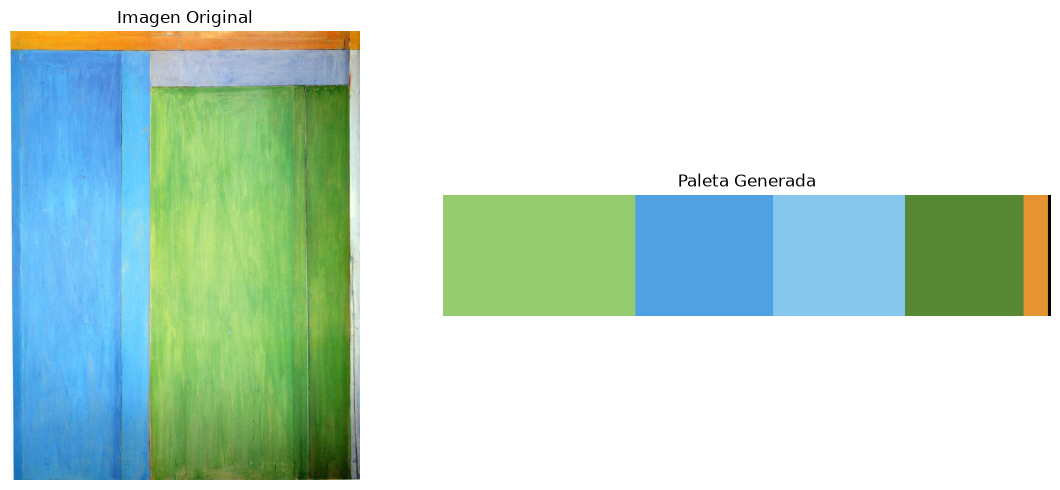

In [15]:
plt.figure(figsize=(12, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_original[5])
plt.axis('off')

# Paleta generada
plt.subplot(1, 2, 2)
plt.title('Paleta Generada')
plt.imshow(paleta_final)
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Evidencia del desempeño del método construido mostrando la paleta generada para al menos cuatro (4) imágenes de diferentes estilos, con la visualización de la distribución de colores en el espacio de dos dimensiones.

Para evidenciar el desempeño del método KMeans, se presentan la paleta generada y la distribución de los colores en un espacio bidimensional mediante t-SNE. Al comparar la paleta con la proyección t-SNE, se puede verificar si el algoritmo está identificando grupos de colores coherentes y representativos de la imagen original. 

En este punto comparamos la imagen original con la paleta obtenida para verificar si los colores principales fueron bien agrupados

Y podemos generar una máscara o imagen segmentada con la expresión `centroids[labels]`. Ten en cuenta que, para visualizar la imagen correctamente, reescalamos los valores de píxeles al rango original de [0, 255], y volvemos a las dimensiones originales con `reshape()`:

In [16]:
def procesar_imagen(img):

    # 1. Buscar automáticamente el mejor número de clusters
    num_clusters = seleccionar_k(img)

    # 2. Crear el pipeline
    pipeline = crear_pipeline(num_clusters)

    # 3. Entrenar KMeans
    pipeline.fit(img)

    # 4. Obtener KMeans del pipeline
    kmeans_model = pipeline.named_steps['modelo']

    labels = kmeans_model.labels_
    centroids = kmeans_model.cluster_centers_

    # 5. Contar cuántos píxeles hay en cada grupo
    counts = np.bincount(labels)

    # 6. Ordenar colores de mayor a menor frecuencia
    orden = np.argsort(counts)[::-1]

    centroids = centroids[orden]
    counts = counts[orden]

    # 7. Volver de 0-1 a 0-255
    centroids = (centroids * 255).astype(np.uint8)

    # 8. Crear paleta
    paleta = crear_paleta(centroids, counts)

    return paleta, num_clusters

In [17]:
img_original

[array([[[ 54,  54,  54],
         [ 58,  58,  58],
         [ 61,  61,  61],
         ...,
         [111, 110,  92],
         [215, 213, 200],
         [220, 221, 207]],
 
        [[ 65,  65,  65],
         [ 64,  64,  64],
         [ 62,  62,  62],
         ...,
         [114, 113,  95],
         [219, 217, 204],
         [226, 227, 213]],
 
        [[ 62,  62,  62],
         [ 62,  62,  62],
         [ 62,  62,  62],
         ...,
         [108, 107,  89],
         [213, 211, 198],
         [220, 221, 207]],
 
        ...,
 
        [[248, 250, 245],
         [250, 252, 247],
         [250, 252, 247],
         ...,
         [245, 251, 251],
         [240, 249, 248],
         [242, 252, 251]],
 
        [[249, 254, 250],
         [244, 250, 246],
         [241, 246, 242],
         ...,
         [245, 251, 251],
         [245, 254, 253],
         [246, 255, 254]],
 
        [[236, 238, 233],
         [236, 241, 235],
         [240, 242, 239],
         ...,
         [248, 252, 251],
  

Creamos listas para guardar las paletas y el número de clústeres de cada imagen, y luego procesamos todas las imágenes una por una

In [18]:
paletas = []
clusters = []

for i in range(len(img_original)):

    print(f"\nProcesando imagen {i + 1} de {len(img_original)}")

    paleta, num_clusters = procesar_imagen(img_original[i])

    paletas.append(paleta)
    clusters.append(num_clusters)


Procesando imagen 1 de 9
K=3 - Silhouette Score=0.5669
K=4 - Silhouette Score=0.5195
K=5 - Silhouette Score=0.4665
K=6 - Silhouette Score=0.4696
K=7 - Silhouette Score=0.4066
K=8 - Silhouette Score=0.3929
K=9 - Silhouette Score=0.3926
K=10 - Silhouette Score=0.3831
K=11 - Silhouette Score=0.3895
K=12 - Silhouette Score=0.3867
K=13 - Silhouette Score=0.3692
K=14 - Silhouette Score=0.3368
K=15 - Silhouette Score=0.3402
K=16 - Silhouette Score=0.3387
K=17 - Silhouette Score=0.3421
K=18 - Silhouette Score=0.3362
K=19 - Silhouette Score=0.3197
K=20 - Silhouette Score=0.3216

Mejor número de grupos: 3

Procesando imagen 2 de 9
K=3 - Silhouette Score=0.4601
K=4 - Silhouette Score=0.4463
K=5 - Silhouette Score=0.4144
K=6 - Silhouette Score=0.4569
K=7 - Silhouette Score=0.4161
K=8 - Silhouette Score=0.4133
K=9 - Silhouette Score=0.4136
K=10 - Silhouette Score=0.3868
K=11 - Silhouette Score=0.3852
K=12 - Silhouette Score=0.3792
K=13 - Silhouette Score=0.3681
K=14 - Silhouette Score=0.3588
K=15 

Generamos la comparación visual para cada imagen, mostrando la obra original y la paleta de colores predominante resultante. Permitiendo evaluar si el número de clusters seleccionado refleja adecuadamente los colores dominantes de cada imagen.

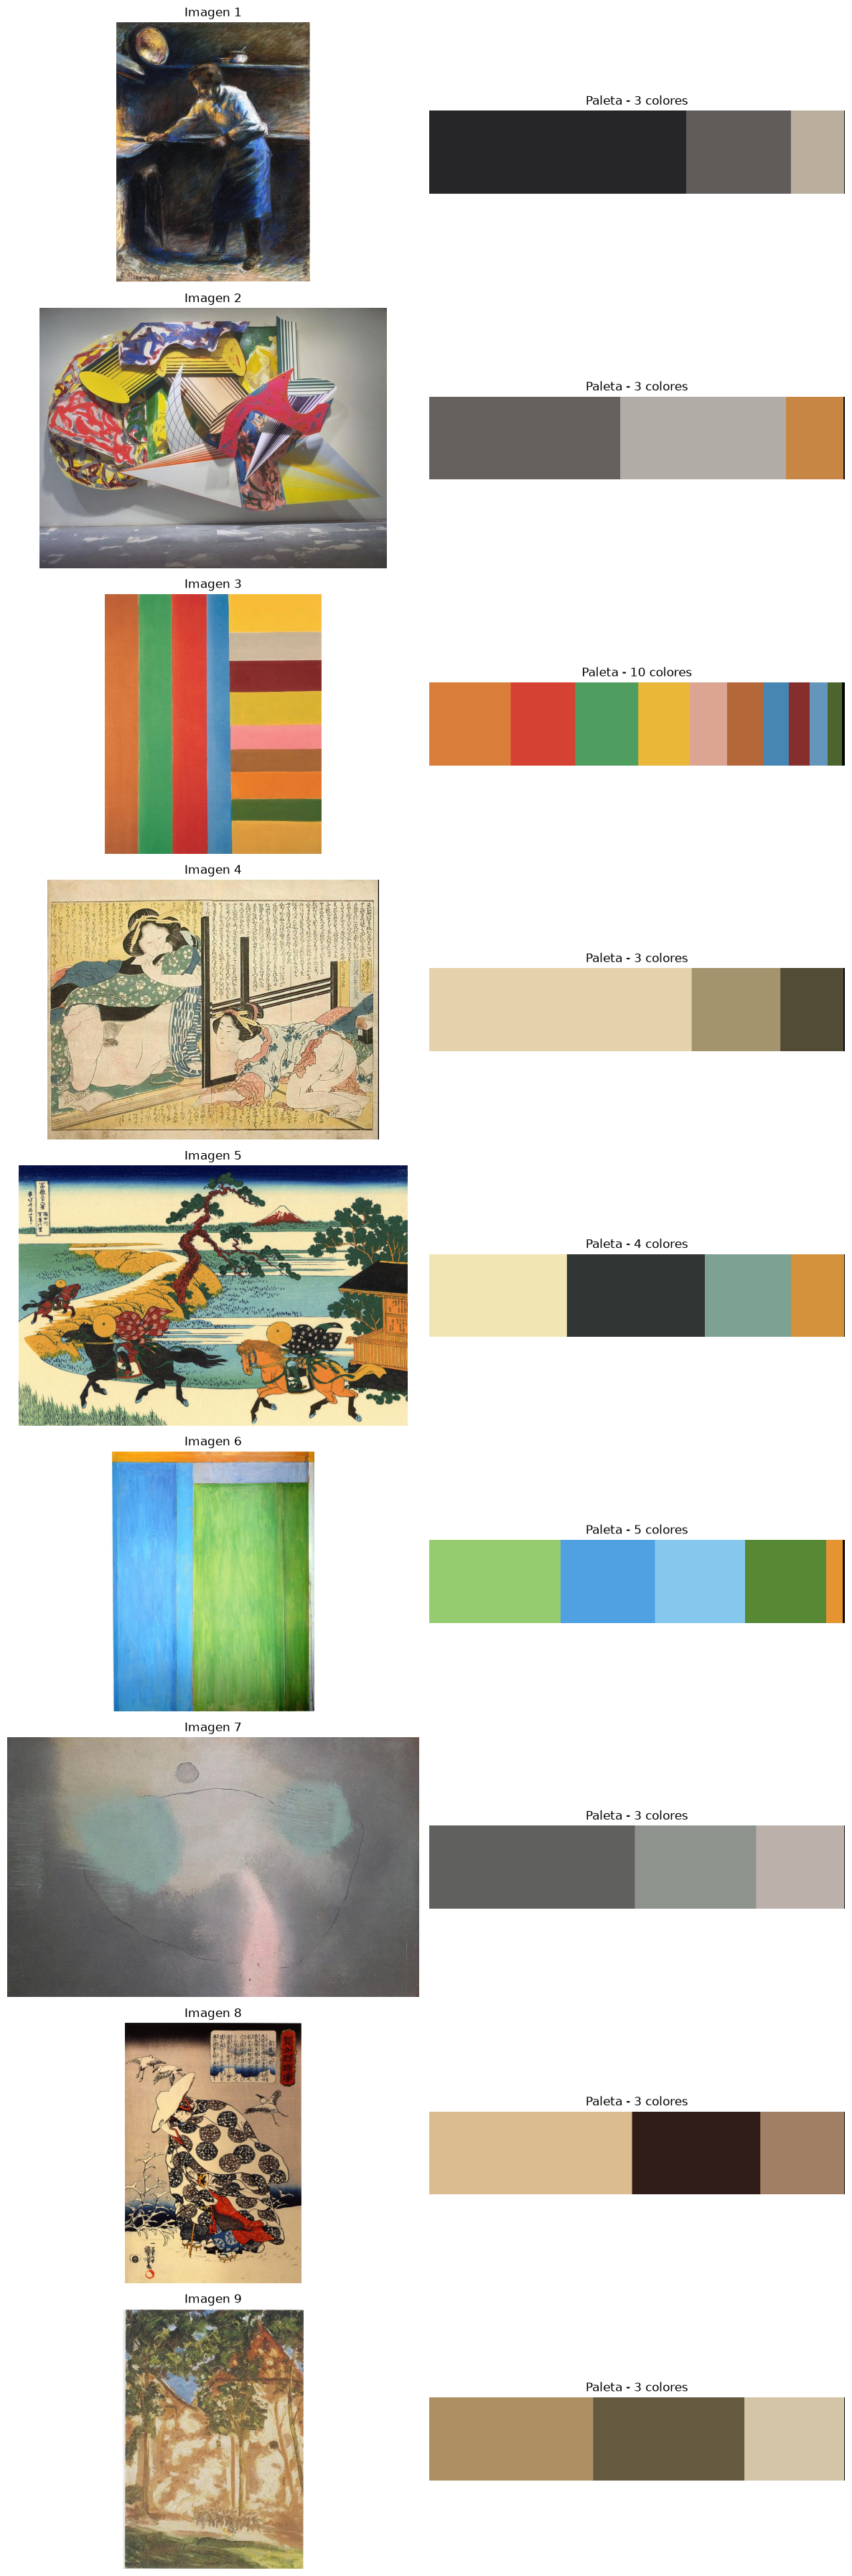

In [19]:
n = len(img_original)

plt.figure(figsize=(12, 4 * n))

for i in range(n):

    # Imagen original
    plt.subplot(n, 2, i * 2 + 1)
    plt.imshow(img_original[i])
    plt.title(f'Imagen {i + 1}')
    plt.axis('off')

    # Paleta
    plt.subplot(n, 2, i * 2 + 2)
    plt.imshow(paletas[i])
    plt.title(f'Paleta - {clusters[i]} colores')
    plt.axis('off')

plt.tight_layout()
plt.show()

Y para finalizar poyectamos los pixeles de cada imagen en un espacio bidimensional con t-SNE para observar cómo se agrupan los colores, permitiendonos observar si los grupos formados por K-means están bien definidos, motrandonos la distribución de clusters visualmente coherentes y separados.

In [20]:
def graficar_tsne(imagen, numero_imagen, k):
    pixeles = imagen.reshape(-1, 3).astype(np.float64)
    pixeles = pixeles / 255.0

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(pixeles)

    cantidad = min(500, len(pixeles))

    generador = np.random.default_rng(42)
    indices = generador.choice(
        len(pixeles),
        cantidad,
        replace=False
    )

    pixeles_muestra = pixeles[indices]
    etiquetas_muestra = etiquetas[indices]

    print('Calculando t-SNE de la imagen', numero_imagen)

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        max_iter=500
    )

    puntos = tsne.fit_transform(pixeles_muestra)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        puntos[:, 0],
        puntos[:, 1],
        c=etiquetas_muestra,
        cmap='tab10',
        s=20,
        alpha=0.7
    )

    plt.title(
        'Distribucion de colores - Imagen ' +
        str(numero_imagen) +
        ' - K=' +
        str(k)
    )

    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(label='Grupo de color')
    plt.show()

Calculando t-SNE de la imagen 1


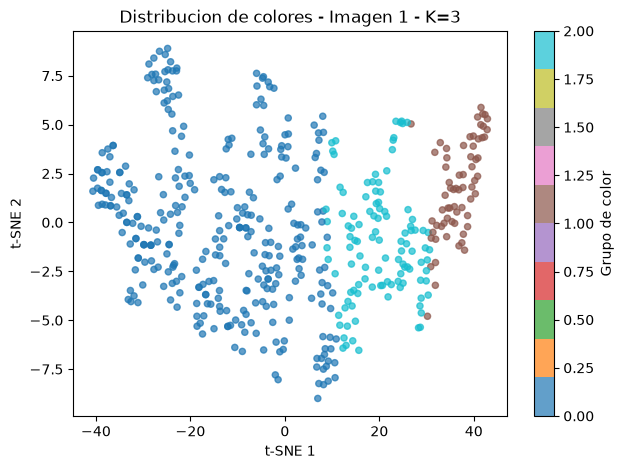

Calculando t-SNE de la imagen 2


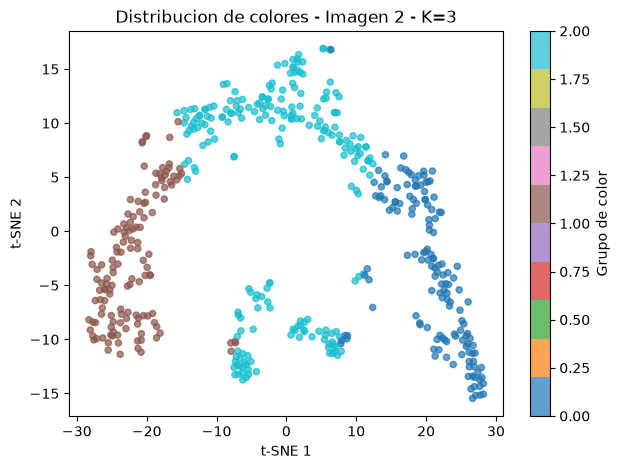

Calculando t-SNE de la imagen 3


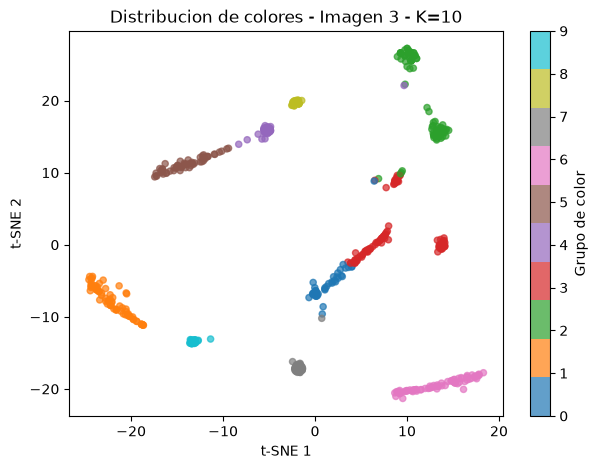

Calculando t-SNE de la imagen 4


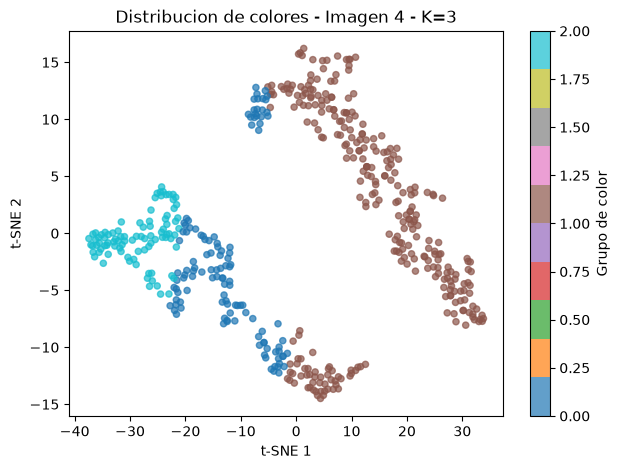

Calculando t-SNE de la imagen 5


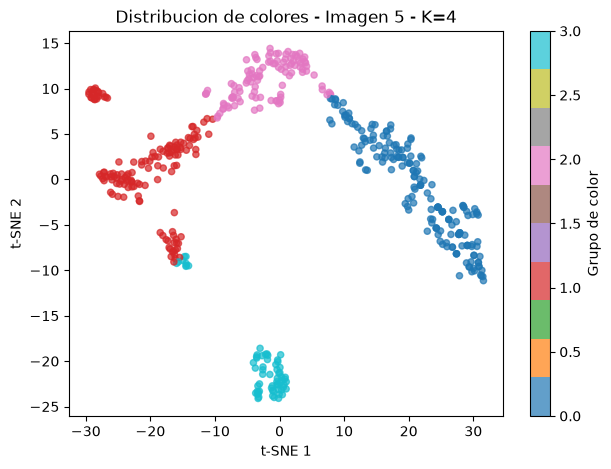

Calculando t-SNE de la imagen 6


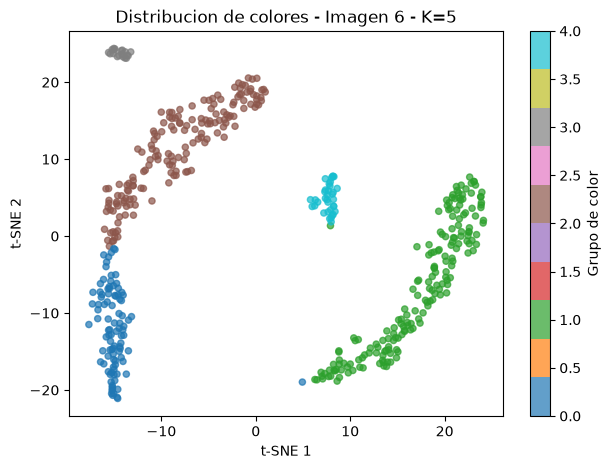

Calculando t-SNE de la imagen 7


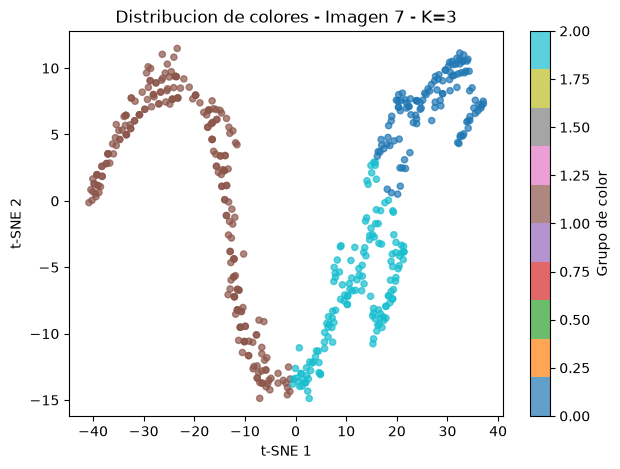

Calculando t-SNE de la imagen 8


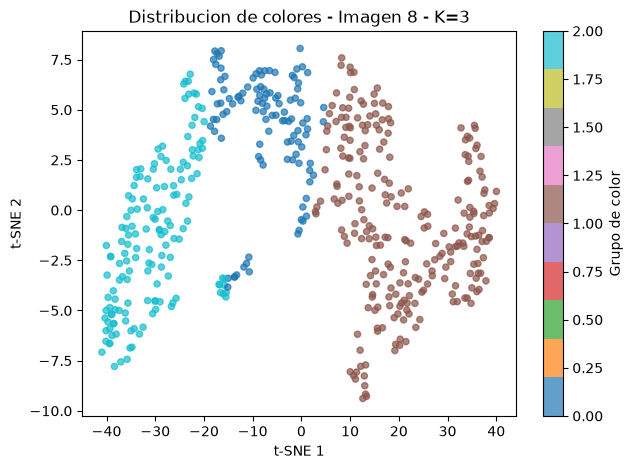

Calculando t-SNE de la imagen 9


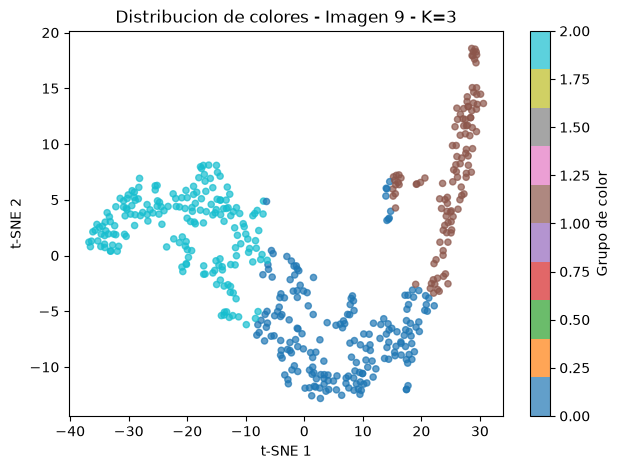

In [21]:
for i in range(len(img_original)):
    imagen = img_original[i]
    k = clusters[i]

    graficar_tsne(
        imagen,
        i + 1,
        k
    )